In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

rppg   = np.load("../outputs/rppg_signal.npy")
gt     = np.loadtxt("../data/subject1/ground_truth.txt")
ppg_gt = gt[0]
hr_gt  = gt[1]

fps    = 29.264106
t      = np.arange(len(rppg)) / fps

print(f"Signal length : {len(rppg)} samples")
print(f"Duration      : {t[-1]:.1f} seconds")
print(f"Mean GT HR    : {hr_gt.mean():.1f} BPM")

Signal length : 1547 samples
Duration      : 52.8 seconds
Mean GT HR    : 106.7 BPM


In [4]:
# FFT
N      = len(rppg)
fft_vals = np.abs(np.fft.rfft(rppg))
freqs    = np.fft.rfftfreq(N, d=1.0/fps)

# Only look in heartbeat range: 0.7–4 Hz
mask      = (freqs >= 0.7) & (freqs <= 4.0)
freqs_hr  = freqs[mask]
fft_hr    = fft_vals[mask]

# Peak frequency = dominant heartbeat frequency
peak_idx  = np.argmax(fft_hr)
peak_freq = freqs_hr[peak_idx]
hr_estimated = peak_freq * 60

print(f"Dominant frequency : {peak_freq:.3f} Hz")
print(f"Estimated HR       : {hr_estimated:.1f} BPM")
print(f"Ground Truth HR    : {hr_gt.mean():.1f} BPM")
print(f"Error              : {abs(hr_estimated - hr_gt.mean()):.1f} BPM")

Dominant frequency : 1.778 Hz
Estimated HR       : 106.7 BPM
Ground Truth HR    : 106.7 BPM
Error              : 0.0 BPM


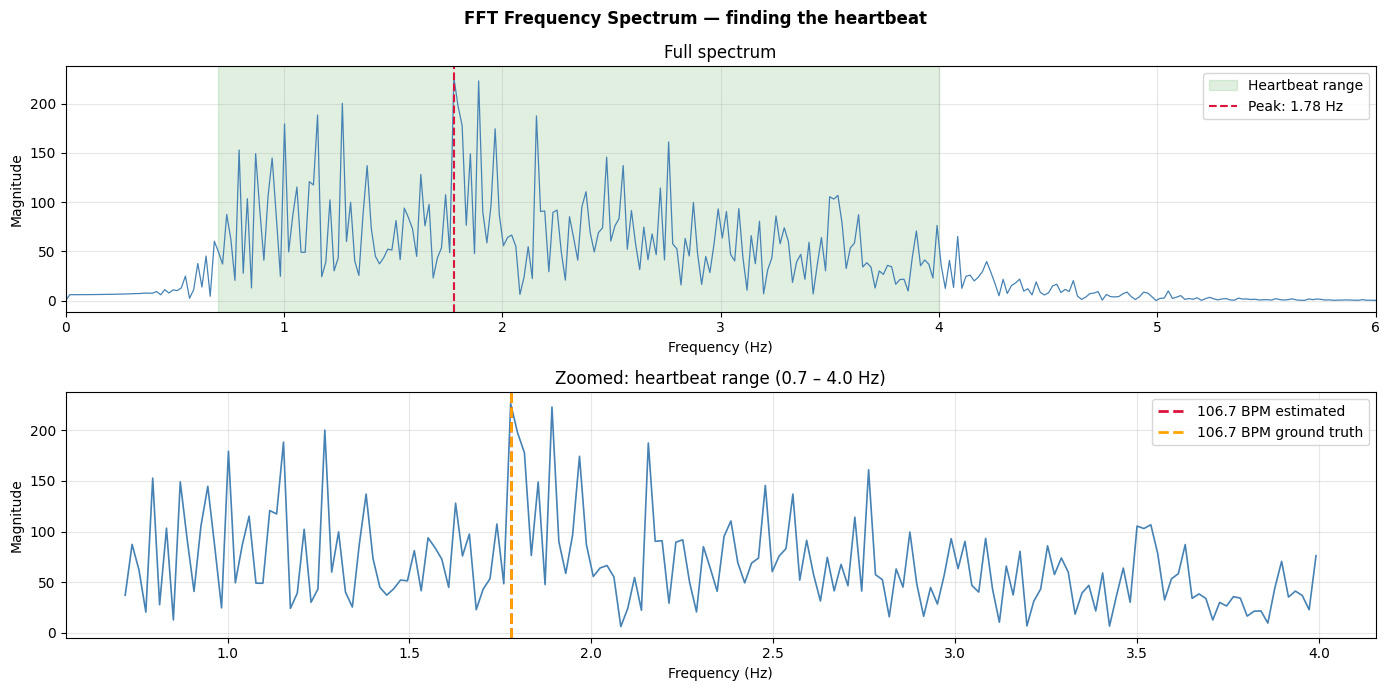

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("FFT Frequency Spectrum — finding the heartbeat", fontweight='bold')

# Full spectrum
axes[0].plot(freqs, fft_vals, color='steelblue', linewidth=0.9)
axes[0].axvspan(0.7, 4.0, alpha=0.12, color='green', label='Heartbeat range')
axes[0].axvline(peak_freq, color='crimson', linewidth=1.5,
                linestyle='--', label=f'Peak: {peak_freq:.2f} Hz')
axes[0].set_title("Full spectrum")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Magnitude")
axes[0].set_xlim([0, 6])
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Zoomed into heartbeat range
axes[1].plot(freqs_hr, fft_hr, color='steelblue', linewidth=1.2)
axes[1].axvline(peak_freq, color='crimson', linewidth=2,
                linestyle='--', label=f'{hr_estimated:.1f} BPM estimated')
axes[1].axvline(hr_gt.mean()/60, color='orange', linewidth=2,
                linestyle='--', label=f'{hr_gt.mean():.1f} BPM ground truth')
axes[1].set_title("Zoomed: heartbeat range (0.7 – 4.0 Hz)")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Magnitude")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/fft_spectrum.png", dpi=150)
plt.show()

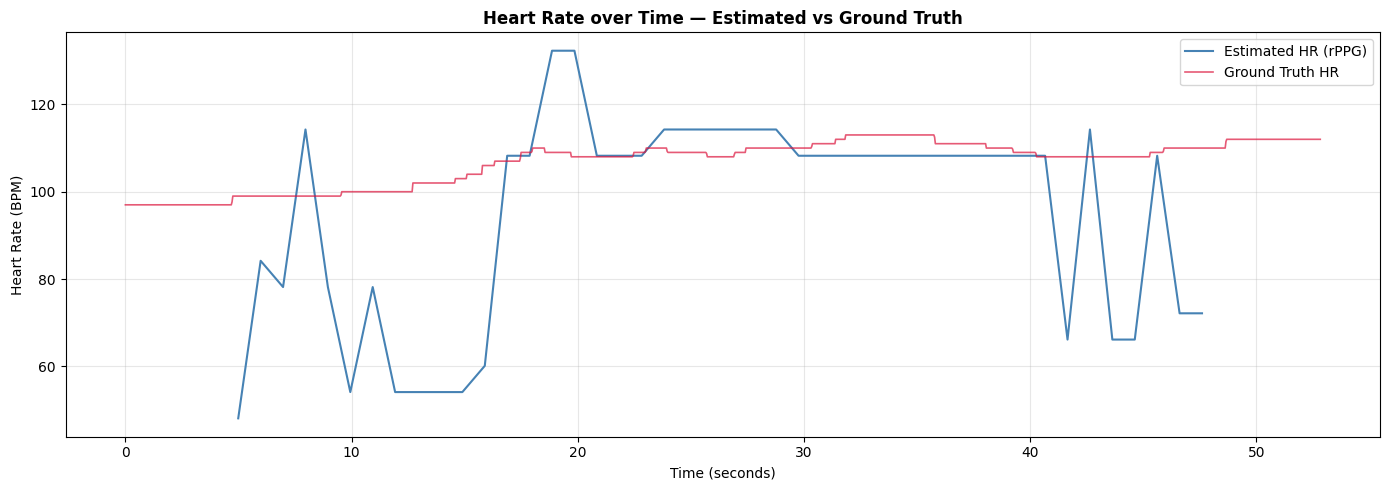

Mean Absolute Error: 17.09 BPM


In [6]:
# Instead of one FFT over the whole signal,
# slide a 10-second window and estimate HR at each step

win_sec  = 10        # window size in seconds
step_sec = 1         # step size in seconds
win_samp = int(win_sec  * fps)
step_samp= int(step_sec * fps)

hr_over_time = []
time_points  = []

for start in range(0, len(rppg) - win_samp, step_samp):
    window   = rppg[start : start + win_samp]
    fft_w    = np.abs(np.fft.rfft(window))
    freqs_w  = np.fft.rfftfreq(len(window), d=1.0/fps)

    mask_w   = (freqs_w >= 0.7) & (freqs_w <= 4.0)
    peak_f   = freqs_w[mask_w][np.argmax(fft_w[mask_w])]

    hr_over_time.append(peak_f * 60)
    time_points.append((start + win_samp // 2) / fps)

hr_over_time = np.array(hr_over_time)
time_points  = np.array(time_points)

# Plot vs ground truth
plt.figure(figsize=(14, 5))
plt.plot(time_points, hr_over_time, color='steelblue',
         linewidth=1.5, label='Estimated HR (rPPG)')
plt.plot(t, hr_gt, color='crimson', linewidth=1.2,
         alpha=0.7, label='Ground Truth HR')
plt.title("Heart Rate over Time — Estimated vs Ground Truth", fontweight='bold')
plt.xlabel("Time (seconds)")
plt.ylabel("Heart Rate (BPM)")
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/hr_over_time.png", dpi=150)
plt.show()

mae = np.mean(np.abs(hr_over_time - hr_gt[
    [int(tp*fps) for tp in time_points]
]))
print(f"Mean Absolute Error: {mae:.2f} BPM")

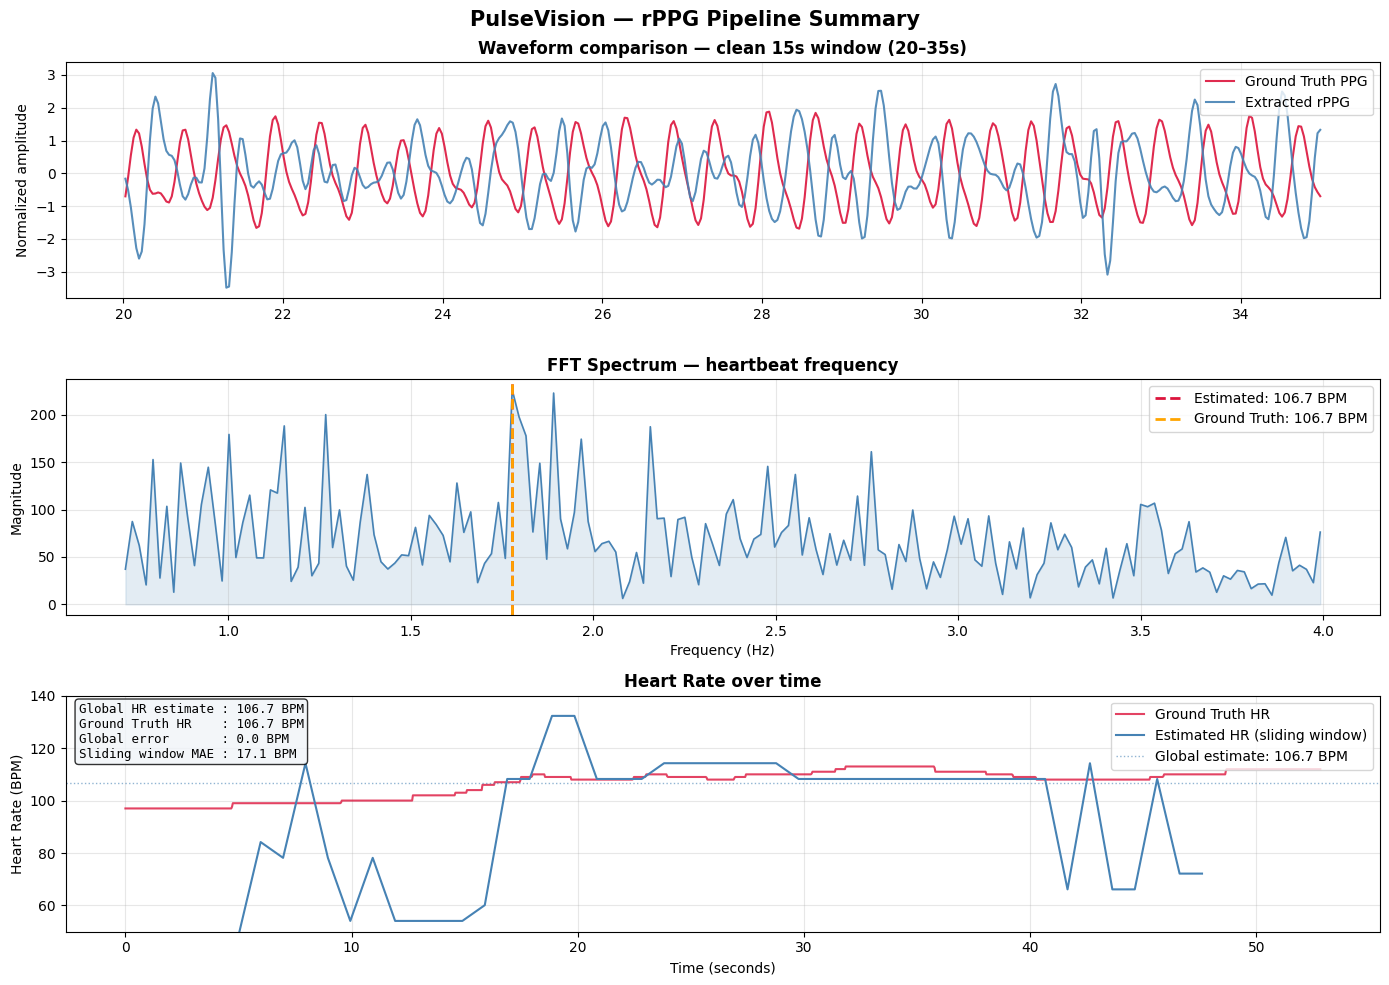

Saved → outputs/pulsevision_summary.png


In [7]:
from scipy.signal import detrend
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut=0.7, highcut=4.0, fs=29.264106, order=4):
    nyq  = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

# Reload ground truth
gt     = np.loadtxt("../data/subject1/ground_truth.txt")
ppg_gt = gt[0]
hr_gt  = gt[1]

# rest of the cell continues unchanged...

# Prepare ground truth PPG (filtered same way as rPPG)
ppg_gt_filtered = bandpass_filter(detrend(ppg_gt))
ppg_gt_filtered = (ppg_gt_filtered - ppg_gt_filtered.mean()) / ppg_gt_filtered.std()

# Use a clean 15-second window away from the motion artifact
mask = (t >= 20) & (t <= 35)

fig = plt.figure(figsize=(14, 10))
fig.suptitle("PulseVision — rPPG Pipeline Summary", fontsize=15, fontweight='bold', y=0.98)

# --- Top: waveform comparison ---
ax1 = fig.add_subplot(3, 1, 1)
ax1.plot(t[mask], ppg_gt_filtered[mask], color='crimson',
         linewidth=1.5, label='Ground Truth PPG', alpha=0.9)
ax1.plot(t[mask], rppg[mask], color='steelblue',
         linewidth=1.5, label='Extracted rPPG', alpha=0.9)
ax1.set_title("Waveform comparison — clean 15s window (20–35s)", fontweight='bold')
ax1.set_ylabel("Normalized amplitude")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Middle: FFT spectrum ---
ax2 = fig.add_subplot(3, 1, 2)
ax2.plot(freqs_hr, fft_hr, color='steelblue', linewidth=1.2)
ax2.axvline(peak_freq, color='crimson', linewidth=2,
            linestyle='--', label=f'Estimated: {hr_estimated:.1f} BPM')
ax2.axvline(hr_gt.mean()/60, color='orange', linewidth=2,
            linestyle='--', label=f'Ground Truth: {hr_gt.mean():.1f} BPM')
ax2.fill_between(freqs_hr, fft_hr, alpha=0.15, color='steelblue')
ax2.set_title("FFT Spectrum — heartbeat frequency", fontweight='bold')
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Magnitude")
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# --- Bottom: HR over time ---
ax3 = fig.add_subplot(3, 1, 3)
ax3.plot(t, hr_gt, color='crimson', linewidth=1.5,
         alpha=0.8, label='Ground Truth HR')
ax3.plot(time_points, hr_over_time, color='steelblue',
         linewidth=1.5, label='Estimated HR (sliding window)')
ax3.axhline(hr_estimated, color='steelblue', linewidth=1,
            linestyle=':', alpha=0.6, label=f'Global estimate: {hr_estimated:.1f} BPM')
ax3.set_title("Heart Rate over time", fontweight='bold')
ax3.set_xlabel("Time (seconds)")
ax3.set_ylabel("Heart Rate (BPM)")
ax3.set_ylim([50, 140])
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# Annotation box
props = dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.8)
summary = (
    f"Global HR estimate : {hr_estimated:.1f} BPM\n"
    f"Ground Truth HR    : {hr_gt.mean():.1f} BPM\n"
    f"Global error       : {abs(hr_estimated - hr_gt.mean()):.1f} BPM\n"
    f"Sliding window MAE : {mae:.1f} BPM"
)
ax3.text(0.01, 0.97, summary, transform=ax3.transAxes,
         fontsize=9, verticalalignment='top',
         bbox=props, fontfamily='monospace')

plt.tight_layout()
plt.savefig("../outputs/pulsevision_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/pulsevision_summary.png")